In [5]:
# Four different types of individuals to test:
from individual import QChromosomeRepairPermutationEncoding, QChromosomePositionEncoding, QChromosomeHashPermutationEncoding, QChromosomeHashMultisetEncoding, QChromosomeHashMultisetImprovedEncoding
from schedules import Schedule
from nsga_population import QMEAPopulation
# Importing libraries
import numpy as np
import pandas as pd
import pdb
from omegaconf import DictConfig
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import seaborn as sns
from typing import List
import math
import decimal
import json
from sympy.combinatorics.graycode import bin_to_gray, gray_to_bin
from or_benchmark import BenchmarkCollection

In [108]:
test_benchmark_collection = BenchmarkCollection(reload_benchmarks=False)
problem_name = "ft10"
cur_n_machines = test_benchmark_collection.benchmark_collection[problem_name]['n_machines']
cur_n_jobs = test_benchmark_collection.benchmark_collection[problem_name]['n_jobs']
cur_jssp_problem = test_benchmark_collection.benchmark_collection[problem_name]['problem_matrix']

test_permutation_5 = QChromosomeHashMultisetImprovedEncoding(cur_n_jobs, cur_n_machines, DictConfig(content={"mutation_rate" : 0.1, "reset_frequency" : 3}), objectives=["Makespan", "Mean Flow Time"], time_log=True)
test_permutation_5.measure()
# Convert bit string to operation based representation
test_permutation_5.convert_permutation()
# Create schedule to evaluate fitness
test_permutation_5.create_schedule("apply_operation_based_bierwirth", cur_jssp_problem, "True")

In [109]:
len(test_permutation_5.x)

307

In [112]:
len(test_bit_string[0:])

305

In [222]:
individual_Train = np.zeros((5000, 300), dtype=int)
rank_train = []
makespan_train = []
mft_train = []
for j in range(5000):
    random_permutation_rank = int(np.random.uniform() * 2**(len(test_permutation_5.x)))
    rank_train.append(random_permutation_rank)
    cur_bin_string = bin(random_permutation_rank)[2:]
    test_bit_string = np.array([int(cur_char) for cur_char in cur_bin_string])
    test_permutation_5.x[0:len(test_bit_string)] = test_bit_string[0:]
    # Convert bit string to operation based representation
    test_permutation_5.convert_permutation()
    # Create schedule to evaluate fitness
    test_permutation_5.create_schedule("apply_operation_based_bierwirth", cur_jssp_problem, "True")
    makespan_train.append(test_permutation_5.schedule.get_makespan())
    mft_train.append(test_permutation_5.schedule.get_mean_flow_time())

    cur_list = test_permutation_5.schedule.operation_list
    new_list = np.zeros(len(cur_list)*3, dtype=int)
    for i, op in enumerate(cur_list):
        map_index = i*3
        new_list[map_index] = cur_list[i].job
        new_list[map_index + 1] = cur_list[i].machine
        new_list[map_index + 2] = cur_list[i].start
        
    individual_Train[j, :] = new_list
    print(j)

rank_test = []
makespan_test = []
mft_test = []
individual_Test = np.zeros((1000, 300), dtype=int)
for j in range(1000):
    random_permutation_rank = int(np.random.uniform() * 2**(len(test_permutation_5.x)))
    rank_test.append(random_permutation_rank)
    cur_bin_string = bin(random_permutation_rank)[2:]
    test_bit_string = np.array([int(cur_char) for cur_char in cur_bin_string])
    test_permutation_5.x[0:len(test_bit_string)] = test_bit_string[0:]
    # Convert bit string to operation based representation
    test_permutation_5.convert_permutation()
    # Create schedule to evaluate fitness
    test_permutation_5.create_schedule("apply_operation_based_bierwirth", cur_jssp_problem, "True")
    makespan_test.append(test_permutation_5.schedule.get_makespan())
    mft_test.append(test_permutation_5.schedule.get_mean_flow_time())

    cur_list = test_permutation_5.schedule.operation_list
    new_list = np.zeros(len(cur_list)*3, dtype=int)
    for i, op in enumerate(cur_list):
        map_index = i*3
        new_list[map_index] = cur_list[i].job
        new_list[map_index + 1] = cur_list[i].machine
        new_list[map_index + 2] = cur_list[i].start
        
    individual_Test[j, :] = new_list
    print(j)



0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [223]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

X_train = sc.fit_transform(individual_Train)
X_test = sc.transform(individual_Test)

In [224]:
# Applying PCA function on training
# and testing set of X component
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

explained_variance = pca.explained_variance_ratio_

In [225]:
len(rank_train)

5000

In [226]:
alt_clusters = np.repeat(np.array([[0, 1, 2, 3, 4]]), 10000, axis=0).ravel()

In [197]:
alt_clusters.shape

(50000,)

In [227]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5, random_state=0, n_init="auto").fit_predict(np.array(rank_train).reshape(-1, 1))

In [209]:
kmeans2 = KMeans(n_clusters=5, random_state=0, n_init="auto").fit_predict(X_train)

In [228]:
test_df = pd.DataFrame({"rank" : rank_train, "class" : kmeans, "dim1" : X_train[:, 0], "dim2" : X_train[:, 1], "dummy" : np.ones(len(rank_train), dtype=int), "makespan" : makespan_train, "mean_flow_time" : mft_train})

In [229]:
test_df

,rank,class,dim1,dim2,dummy,makespan,mean_flow_time
0,1995666866121251264813140693559444566035367789...,4,3.914780,-0.775529,1,1349.0,1003.4
1,1170596204421935460938289310571705141872937355...,2,6.448828,4.220640,1,1370.0,1038.7
2,4400756806152047963592175575284165198739693167...,3,1.765232,-3.454470,1,1214.0,962.8
3,1449554939062510843595190235478202504357407510...,3,-6.291458,2.480713,1,1269.0,906.1
4,1314666518041670426058002621282864393362336552...,2,-4.842642,-0.423213,1,1218.0,894.4
...,...,...,...,...,...,...,...
4995,6577391683966131287069177946171270888217571596...,3,13.224514,1.492662,1,1349.0,1127.6
4996,5827653384144907354607894002424884112900305317...,1,1.264592,-2.717424,1,1207.0,1016.5
4997,5256705588368073764389402299604680284890712725...,3,-10.925309,-3.938930,1,1157.0,929.1
4998,8752119269634499899387697648597506971727468901...,1,6.586443,6.527900,1,1342.0,1016.0


<Axes: xlabel='makespan', ylabel='mean_flow_time'>

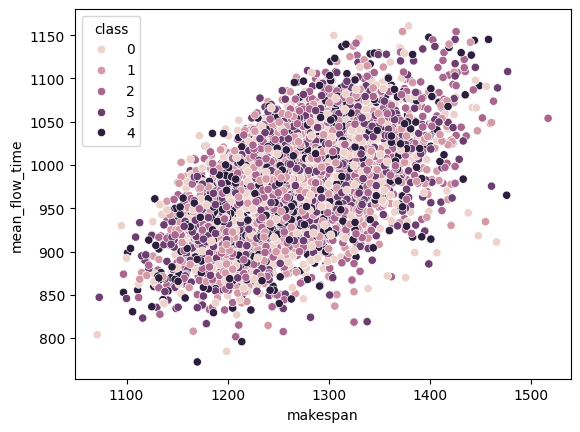

In [230]:
sns.scatterplot(data=test_df, x="makespan", y="mean_flow_time", hue="class")

<Axes: xlabel='dim1', ylabel='dim2'>

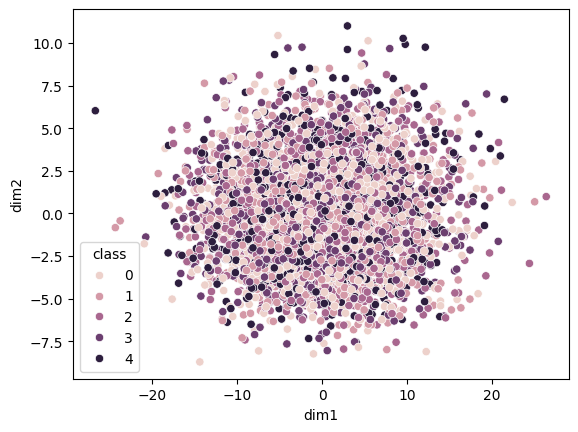

In [220]:
sns.scatterplot(data=test_df, x="dim1", y="dim2", hue="class")

<Axes: xlabel='rank', ylabel='dummy'>

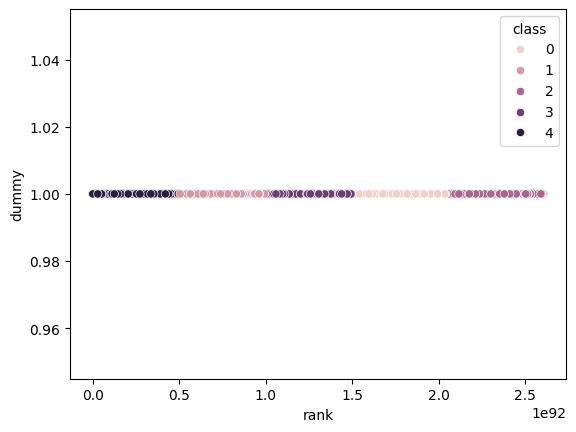

In [221]:
sns.scatterplot(data=test_df, x="rank", y="dummy", hue="class")

In [149]:
kmeans

array([0, 4, 0, ..., 4, 3, 1])

In [141]:
abs(test_df - test_df.mean())

,rank,dim1,dim2
0,3917728524938003204257377469118775713590681016...,2.224104,1.050853
1,2436503142354762131372925171649859474381682137...,9.134422,4.570362
2,6243416766424922196572867831728300876876742068...,3.677562,1.695018
3,1220561332868514982586067275240540741613556606...,8.997941,4.818366
4,2133934678198654187651920231856349347347729502...,9.008689,1.872511
...,...,...,...
1995,8033764659630601559776883633973278351409578183...,0.335543,1.092104
1996,9116959755330102765837622342298174684098585428...,21.693535,0.420047
1997,1900475601123328271329230140756754322345056049...,8.421066,0.03783
1998,9419518244909134028364231047249795892771159896...,1.717954,2.333304


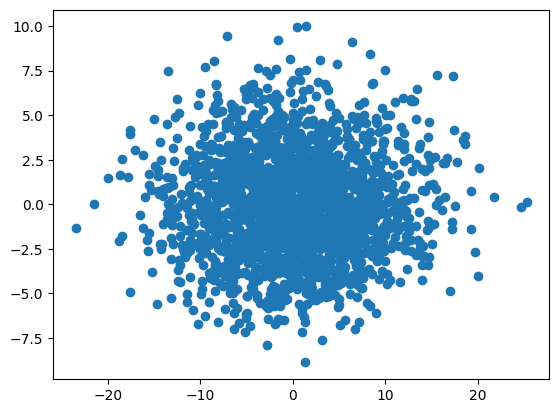

In [142]:
plt.scatter(X_train[:, 0], X_train[:, 1])

In [143]:
rank_train

[...,
 ...]